In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import matplotlib.pyplot as plt
#k-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
# Train-test split
from sklearn.model_selection import train_test_split
# Accuracy Score
from sklearn.metrics import accuracy_score
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [35]:
qb_data = pd.read_csv("QB_information.csv")

In [36]:
qb_data

,name,teams,passing_yards,tds,ints,passer_rating,numb,wins,superbowls,hof,year_drafted
0,Tom Brady,Patriots/Buccaneers,89214,649,212,97.0,12,251,7,1,2000
1,Drew Brees,Chargers/Saints,80358,571,243,99.0,9,172,1,1,2001
2,Peyton Manning,Colts/Broncos,71940,539,251,97.0,18,186,2,1,1998
3,Brett Favre,Packers/Jets/Vikings,71838,508,336,86.0,4,186,1,1,1991
4,Ben Roethlisberger,Steelers,64088,418,211,94.0,7,165,2,0,2004
...,...,...,...,...,...,...,...,...,...,...,...
95,Lynn Dickey,Cowboys/Bears/49ers,22362,261,99,91.9,13,51,3,0,1971
96,Bernie Kosar,Browns,22029,334,111,99.9,19,53,0,0,1985
97,Marc Bulger,Rams,21660,130,116,71.0,13,42,0,0,2002
98,Neil Lomax,49ers/Jets/Steelers,21490,282,130,80.8,15,47,0,0,1981


In [37]:
stats = ['passing_yards', 'tds', 'ints', 'passer_rating']
hof = qb_data[qb_data['hof'] == 1][stats].dropna()
non_hof = qb_data[qb_data['hof'] == 0][stats].dropna() # Create two classes of players for hof and non hof

C:\Users\westo\AppData\Local\Temp\ipykernel_18312\4111846751.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([non_hof, hof], labels=['Non-HOF', 'HOF'])
C:\Users\westo\AppData\Local\Temp\ipykernel_18312\4111846751.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([non_hof, hof], labels=['Non-HOF', 'HOF'])
C:\Users\westo\AppData\Local\Temp\ipykernel_18312\4111846751.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([non_hof, hof], labels=['Non-HOF', 'HOF'])
C:\Users\westo\AppData\Local\Temp\ipykernel_18312\4111846751.py:7: MatplotlibDeprecationWarning: The 'labels' pa

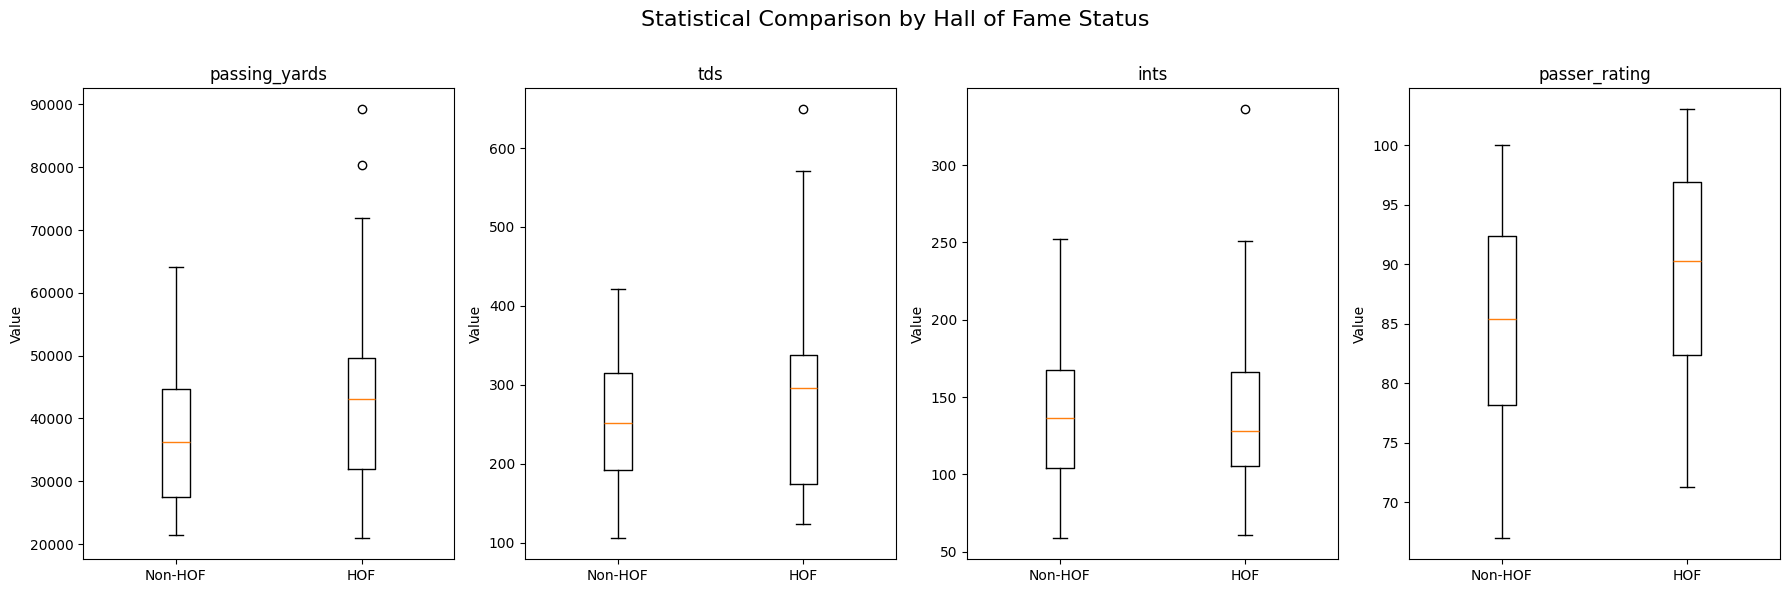

In [38]:
import matplotlib.pyplot as plt

# List of statistics to compare between HOF and Non-HOF quarterbacks
stats = ['passing_yards', 'tds', 'ints', 'passer_rating']

# Create a figure with 1 row and a number of subplots equal to the number of stats
fig, axs = plt.subplots(1, len(stats), figsize=(18, 6))

# Loop over each stat and its index
for i, stat in enumerate(stats):
    # Get the non-null values of the stat for HOF quarterbacks
    hof = qb_data[qb_data['hof'] == 1][stat].dropna()
    
    # Get the non-null values of the stat for non-HOF quarterbacks
    non_hof = qb_data[qb_data['hof'] == 0][stat].dropna()
    
    # Create a boxplot comparing non-HOF and HOF values for this stat
    axs[i].boxplot([non_hof, hof], labels=['Non-HOF', 'HOF'])
    
    # Set the title of the current subplot to the stat name
    axs[i].set_title(stat)
    
    # Set the y-axis label to 'Value' for clarity
    axs[i].set_ylabel('Value')

# Set a main title for the entire figure
fig.suptitle('Statistical Comparison by Hall of Fame Status', fontsize=16)
# Adjust spacing between subplots to prevent overlap
plt.tight_layout()
plt.show()

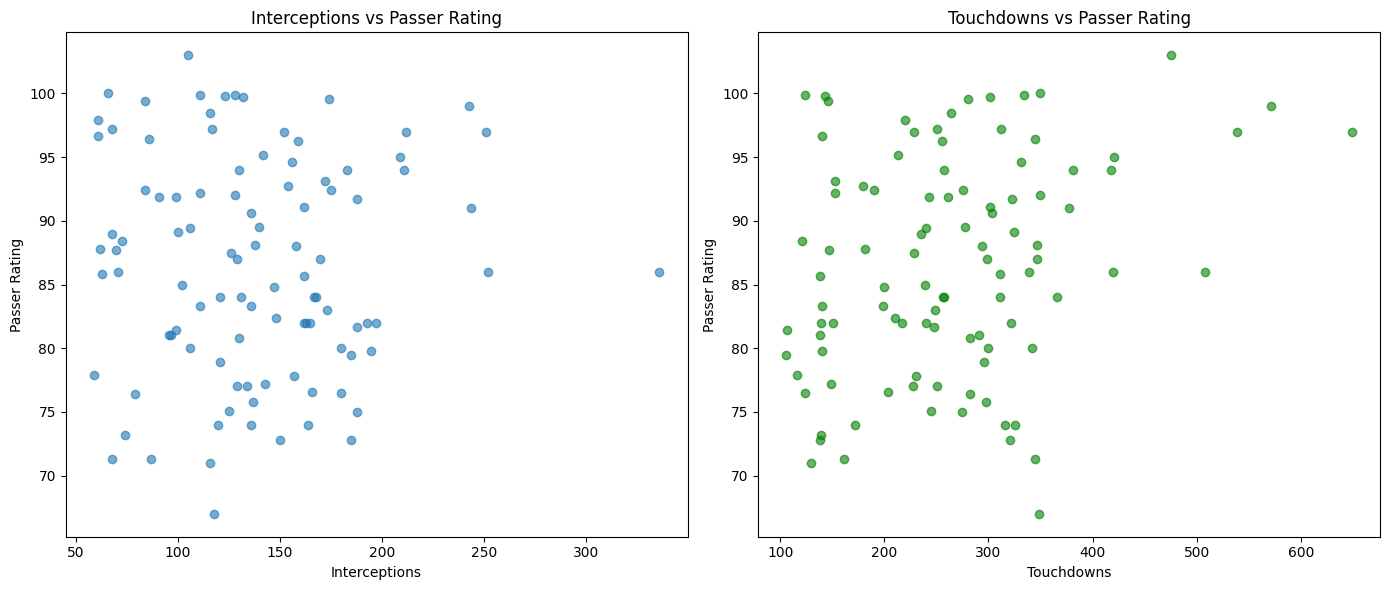

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Interceptions vs Passer Rating
ax1.scatter(qb_data['ints'], qb_data['passer_rating'], alpha=0.6)
ax1.set_title('Interceptions vs Passer Rating')
ax1.set_xlabel('Interceptions')
ax1.set_ylabel('Passer Rating')

# Touchdowns vs Passer Rating
ax2.scatter(qb_data['tds'], qb_data['passer_rating'], alpha=0.6, color='green')
ax2.set_title('Touchdowns vs Passer Rating')
ax2.set_xlabel('Touchdowns')
ax2.set_ylabel('Passer Rating')

plt.tight_layout()
plt.show()

C:\Users\westo\AppData\Local\Temp\ipykernel_18312\1604532922.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = qb_data.groupby('Decade')['wins'].apply(list)
C:\Users\westo\AppData\Local\Temp\ipykernel_18312\1604532922.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped.dropna(), labels=grouped.dropna().index)


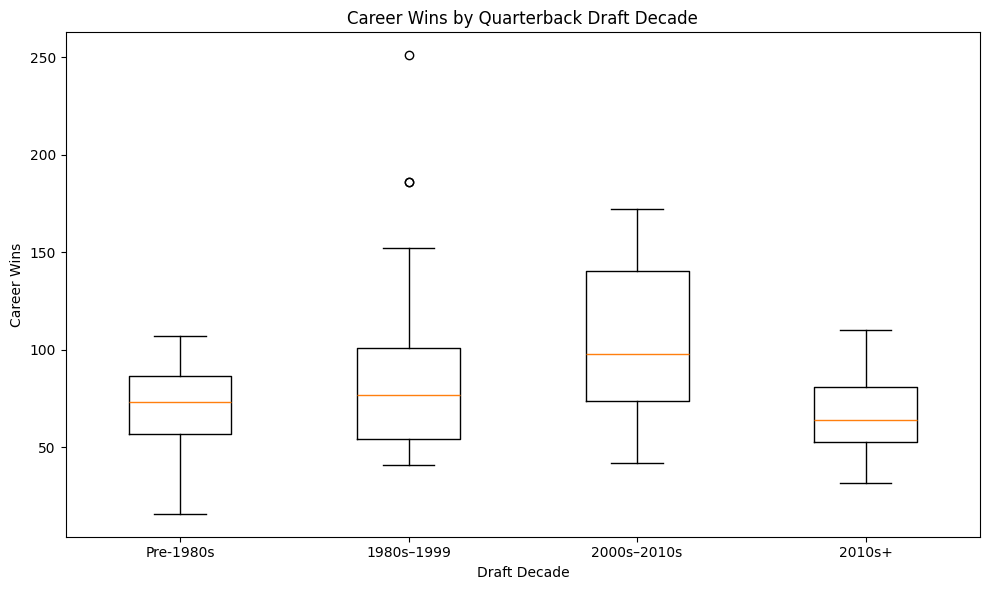

In [40]:
# Convert draft year
qb_data['year_drafted'] = pd.to_numeric(qb_data['year_drafted'], errors='coerce')

# Define decade bins
bins = [0, 1980, 2000, 2010, 2030]
labels = ['Pre-1980s', '1980s–1999', '2000s–2010s', '2010s+']
qb_data['Decade'] = pd.cut(qb_data['year_drafted'], bins=bins, labels=labels)

# Prepare data
grouped = qb_data.groupby('Decade')['wins'].apply(list)

# Create boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(grouped.dropna(), labels=grouped.dropna().index)
plt.title('Career Wins by Quarterback Draft Decade')
plt.xlabel('Draft Decade')
plt.ylabel('Career Wins')
plt.tight_layout()
plt.show()

In [41]:
correlation_matrix = qb_data[['tds', 'ints', 'passing_yards', 'passer_rating', 'wins']].corr()
print("Correlation Matrix:\n", correlation_matrix)

Correlation Matrix:
                     tds      ints  passing_yards  passer_rating      wins
tds            1.000000  0.384862       0.681334       0.281842  0.655931
ints           0.384862  1.000000       0.455959       0.009987  0.505594
passing_yards  0.681334  0.455959       1.000000       0.179432  0.804635
passer_rating  0.281842  0.009987       0.179432       1.000000  0.200317
wins           0.655931  0.505594       0.804635       0.200317  1.000000


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Prepare features and target
features = qb_data[['passing_yards', 'tds', 'ints', 'passer_rating', 'wins']].dropna()
labels = qb_data['hof'][features.index]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
print("\nFeature Coefficients:")
for feature, coef in zip(features.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Confusion Matrix:
 [[21  2]
 [ 5  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86        23
           1       0.50      0.29      0.36         7

    accuracy                           0.77        30
   macro avg       0.65      0.60      0.61        30
weighted avg       0.74      0.77      0.74        30


Feature Coefficients:
passing_yards: 0.0000
tds: -0.0038
ints: -0.0040
passer_rating: 0.0242
wins: 0.0222


In [43]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(qb_data['hof'], qb_data['superbowls'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test Results")
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}, Degrees of Freedom = {dof}")
print("Contingency Table:\n", contingency_table)

Chi-Square Test Results
Chi2 = 29.45, p-value = 0.0000, Degrees of Freedom = 5
Contingency Table:
 superbowls   0  1  2  3  4  7
hof                          
0           62  6  5  1  0  0
1            8  9  4  2  2  1
